# Week 1 — Image basics and I/O

Goals of this notebook:

1. Load a 2D natural image and a 3D NIfTI medical volume in Python.
2. Inspect shape, dtype, and intensity range.
3. Plot the central axial / sagittal / coronal slices of a 3D volume.
4. Plot the **intensity histogram** and confirm that *colormap* and *data* are independent.
5. Apply a 5×5 Gaussian filter and compare PSNR before/after.

Companion reading: `week_1/Readme.md` and `handbook_main.pdf` chapter 'Week 1'.

## Setup

Activate the `mic_soc` environment first. If `nibabel` and `scikit-image` are not yet installed, run:

```bash
pip install nibabel scikit-image
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, filters, metrics
from pathlib import Path

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
print('numpy version :', np.__version__)

numpy version : 2.4.4


## 1. A 2D natural image (no medical scanner needed)

scikit-image ships a few sample images. Let's start with `camera` (a classic 8-bit grayscale 512×512).

shape : (512, 512)
dtype : uint8
min/max : 0 255
mean / std : 129.06072616577148 73.64484655630552


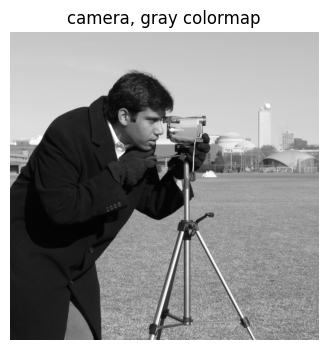

In [2]:
img = data.camera()  # uint8, (512, 512)
print('shape :', img.shape)
print('dtype :', img.dtype)
print('min/max :', img.min(), img.max())
print('mean / std :', img.mean(), img.std())

plt.imshow(img, cmap='gray')
plt.title('camera, gray colormap')
plt.axis('off')
plt.show()

### Colormap ≠ data

The same `img` array can be rendered under any colormap. The *data* never changes.

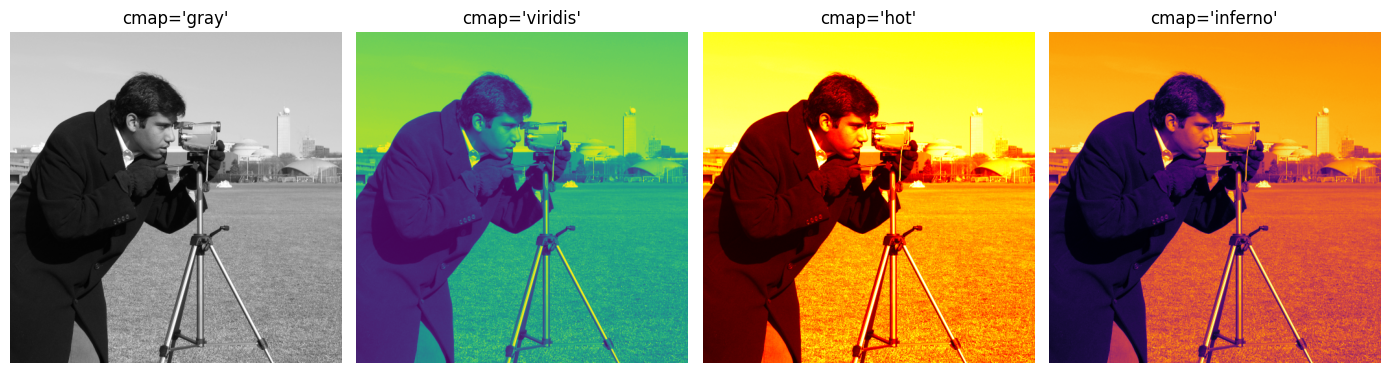

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cmap in zip(axes, ['gray', 'viridis', 'hot', 'inferno']):
    ax.imshow(img, cmap=cmap)
    ax.set_title(f"cmap='{cmap}'")
    ax.axis('off')
plt.tight_layout(); plt.show()

## 2. The intensity histogram

Always look at the histogram alongside the image. Many medical-imaging algorithms (thresholding, histogram equalisation, MAP denoising) depend on it directly.

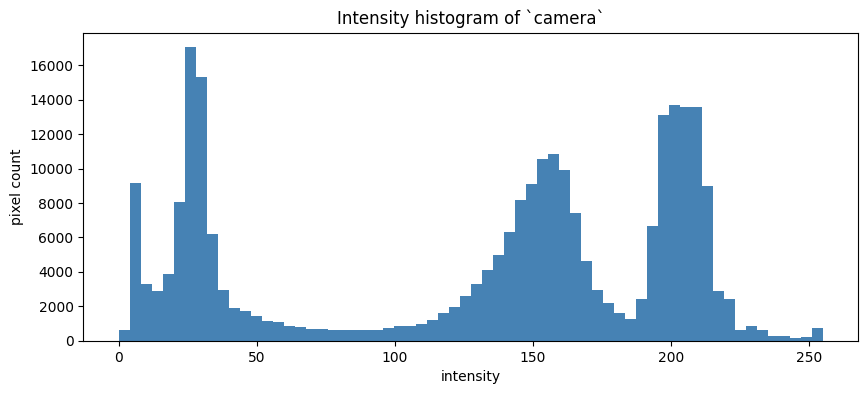

In [4]:
plt.hist(img.ravel(), bins=64, color='steelblue')
plt.title('Intensity histogram of `camera`')
plt.xlabel('intensity')
plt.ylabel('pixel count')
plt.show()

## 3. Loading a 3D NIfTI volume

Medical scanners save volumes in formats like NIfTI (`.nii`, `.nii.gz`) or DICOM. We'll use `nibabel` for NIfTI.

**If you have a NIfTI file locally**, put it at `../data/brain.nii.gz` and run the cell below. 
**If not**, the next cell creates a synthetic 3D 'volume' of three concentric ellipsoids so you can still run the notebook end-to-end.

In [5]:
# Try to load a real volume; fall back to a synthetic phantom.
real_volume_path = Path('../data/brain.nii.gz')
volume = None

if real_volume_path.exists():
    import nibabel as nib
    nii = nib.load(real_volume_path)
    volume = np.asarray(nii.get_fdata())
    print('Loaded NIfTI:', real_volume_path)
    print('shape :', volume.shape, 'dtype:', volume.dtype)
    print('voxel spacing (mm):', nii.header.get_zooms())
else:
    # Synthetic phantom: three nested ellipsoids inside a 96^3 cube.
    N = 96
    z, y, x = np.indices((N, N, N)) - N//2
    r2 = (x/40)**2 + (y/35)**2 + (z/30)**2
    volume = np.zeros((N, N, N), dtype=np.float32)
    volume[r2 < 1.0] = 0.4   # outer
    volume[r2 < 0.5] = 0.7   # mid
    volume[r2 < 0.2] = 1.0   # inner
    print('No NIfTI found; using synthetic phantom.')
    print('shape :', volume.shape, 'dtype:', volume.dtype)

No NIfTI found; using synthetic phantom.
shape : (96, 96, 96) dtype: float32


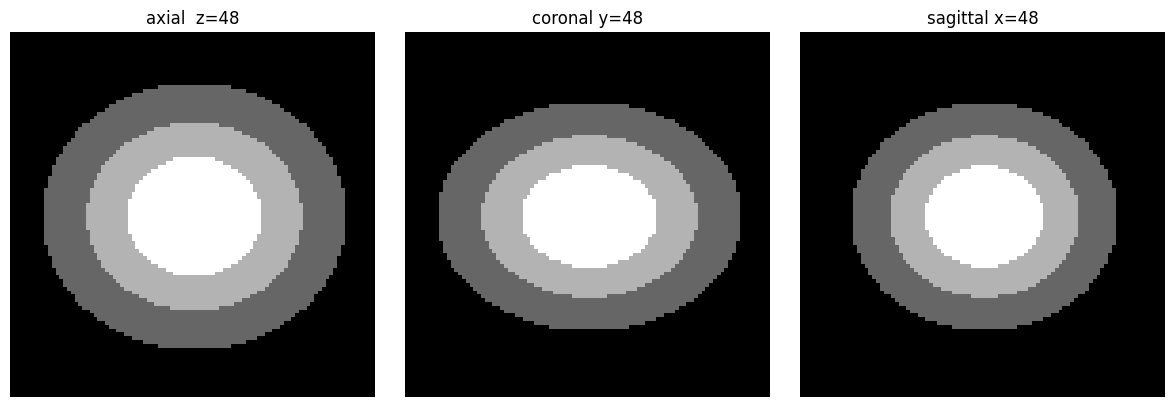

In [6]:
# Central slice in each of the three axes
z0, y0, x0 = [s // 2 for s in volume.shape]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(volume[z0, :, :], cmap='gray');   axes[0].set_title(f'axial  z={z0}')
axes[1].imshow(volume[:, y0, :], cmap='gray');   axes[1].set_title(f'coronal y={y0}')
axes[2].imshow(volume[:, :, x0], cmap='gray');   axes[2].set_title(f'sagittal x={x0}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Add noise, then denoise with a Gaussian filter

This is your first 'classical' denoising experiment. We compare the PSNR of the noisy image and the filtered image. PSNR (peak signal-to-noise ratio) is a standard reconstruction metric:

$$\mathrm{PSNR}(x, \hat x) = 10 \log_{10}\!\left( \frac{\max(x)^2}{\frac{1}{N}\sum_i (x_i - \hat x_i)^2}\right)$$

PSNR noisy    = 20.45 dB
PSNR denoised = 26.41 dB  (gain: +5.96 dB)


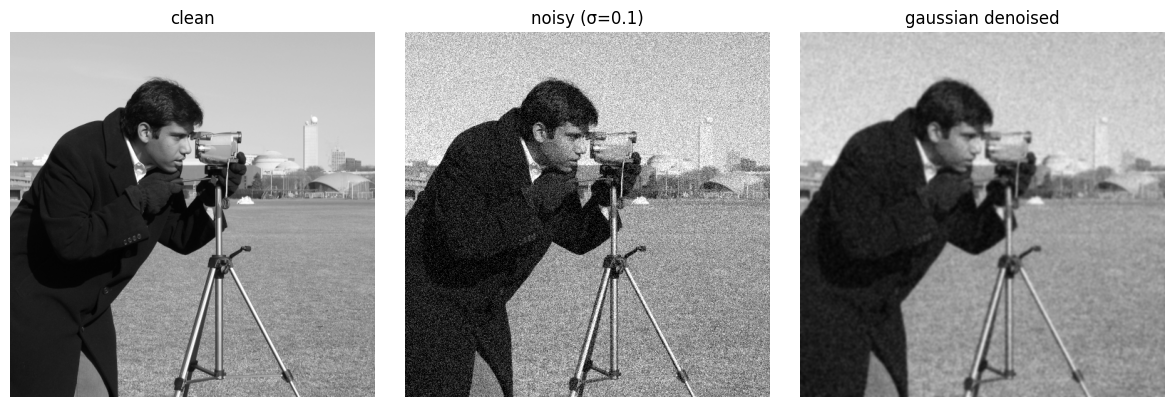

In [7]:
clean = img.astype(np.float32) / 255.0     # in [0, 1]
noisy = clean + np.random.normal(0.0, 0.10, size=clean.shape)
noisy = np.clip(noisy, 0, 1)

denoised = filters.gaussian(noisy, sigma=1.5)

psnr_noisy    = metrics.peak_signal_noise_ratio(clean, noisy,    data_range=1.0)
psnr_denoised = metrics.peak_signal_noise_ratio(clean, denoised, data_range=1.0)
print(f'PSNR noisy    = {psnr_noisy:5.2f} dB')
print(f'PSNR denoised = {psnr_denoised:5.2f} dB  (gain: {psnr_denoised - psnr_noisy:+.2f} dB)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [clean, noisy, denoised], ['clean', 'noisy (σ=0.1)', 'gaussian denoised']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Your turn (exercises)

1. Change the noise standard deviation to 0.05, 0.20, 0.40. Plot PSNR vs. noise level.
2. Replace the Gaussian filter with a **mean (box) filter** of size 5×5. Compare visually — which preserves edges better?
3. Compute the 2D Fourier transform of `clean` and of `noisy`. Plot the log-magnitude. Where does the noise show up in the spectrum?
4. Take the brain volume (real or synthetic), pick one slice, and repeat steps 4 above on it.

## What's next

Notebook `02_probability_refresher.ipynb` walks you through the math of **MLE vs MAP** for the mean of a Gaussian, with simulations. This sets up Week 2's Bayesian denoising properly.

---
## Exercise Solutions

The four exercises from the 'Your turn' section, solved in order.

### Exercise 1 — PSNR vs. noise level

We regenerate `noisy` at three standard deviations (0.05, 0.20, 0.40), apply the same 5×5-equivalent Gaussian filter (`sigma=1.5`), and plot PSNR before/after filtering as a function of noise level.

sigma=0.05  PSNR noisy= 26.17 dB  PSNR denoised= 27.08 dB  gain=+0.91 dB
sigma=0.20  PSNR noisy= 15.06 dB  PSNR denoised= 24.19 dB  gain=+9.12 dB
sigma=0.40  PSNR noisy= 10.37 dB  PSNR denoised= 19.40 dB  gain=+9.02 dB


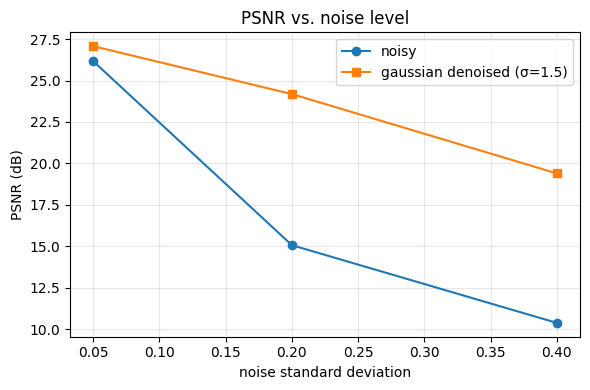

In [8]:
noise_levels = [0.05, 0.20, 0.40]
psnr_noisy_list, psnr_denoised_list = [], []

for s in noise_levels:
    noisy_s = np.clip(clean + np.random.normal(0.0, s, size=clean.shape), 0, 1)
    denoised_s = filters.gaussian(noisy_s, sigma=1.5)
    psnr_noisy_list.append(metrics.peak_signal_noise_ratio(clean, noisy_s, data_range=1.0))
    psnr_denoised_list.append(metrics.peak_signal_noise_ratio(clean, denoised_s, data_range=1.0))

for s, pn, pd in zip(noise_levels, psnr_noisy_list, psnr_denoised_list):
    print(f'sigma={s:4.2f}  PSNR noisy={pn:6.2f} dB  PSNR denoised={pd:6.2f} dB  gain={pd-pn:+.2f} dB')

plt.figure(figsize=(6, 4))
plt.plot(noise_levels, psnr_noisy_list, 'o-', label='noisy')
plt.plot(noise_levels, psnr_denoised_list, 's-', label='gaussian denoised (σ=1.5)')
plt.xlabel('noise standard deviation')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs. noise level')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** PSNR of the noisy image drops steeply and roughly linearly in log-noise terms as σ grows. The Gaussian filter still helps at every level (the gap between the two curves widens), but the *absolute* denoised PSNR also decreases — a fixed-bandwidth linear filter cannot fully recover detail once the noise variance dominates the signal, and at high noise it starts trading noise for blur rather than truly reconstructing the image.

### Exercise 2 — Mean (box) filter vs. Gaussian filter

We repeat the sigma=0.10 experiment from Section 4, but denoise with a 5×5 mean/box filter (`filters.rank`-free version: use `scipy.ndimage.uniform_filter` or a uniform `skimage` footprint) and compare it side-by-side with the Gaussian result, especially around edges (the tripod legs / horizon line in `camera`).

PSNR gaussian (σ=1.5) = 26.42 dB
PSNR box (5x5)        = 25.87 dB


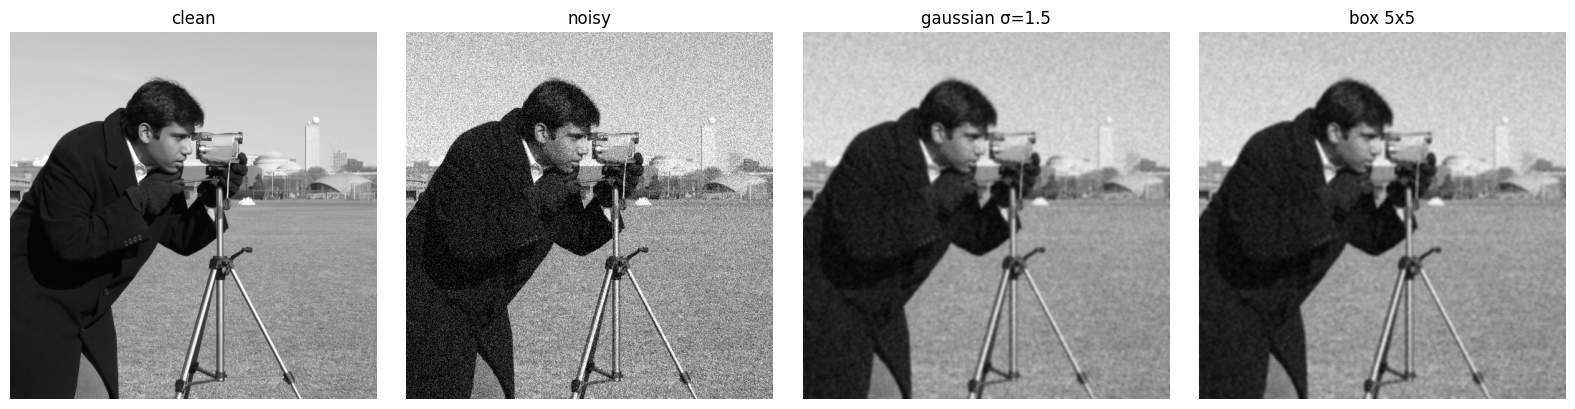

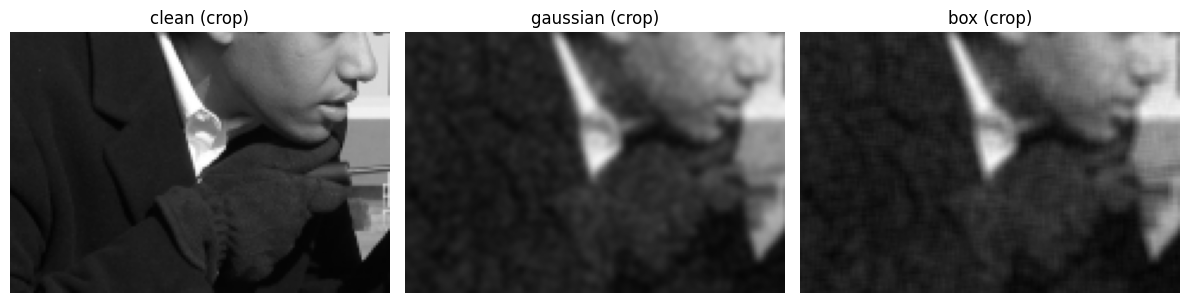

In [9]:
from scipy.ndimage import uniform_filter

noisy_02 = np.clip(clean + np.random.normal(0.0, 0.10, size=clean.shape), 0, 1)

gauss_denoised = filters.gaussian(noisy_02, sigma=1.5)
box_denoised   = uniform_filter(noisy_02, size=5)  # 5x5 mean filter

psnr_gauss = metrics.peak_signal_noise_ratio(clean, gauss_denoised, data_range=1.0)
psnr_box   = metrics.peak_signal_noise_ratio(clean, box_denoised,   data_range=1.0)
print(f'PSNR gaussian (σ=1.5) = {psnr_gauss:5.2f} dB')
print(f'PSNR box (5x5)        = {psnr_box:5.2f} dB')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, t in zip(axes, [clean, noisy_02, gauss_denoised, box_denoised],
                      ['clean', 'noisy', 'gaussian σ=1.5', 'box 5x5']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

# Zoom on an edge-rich region to compare edge preservation
y0, y1, x0, x1 = 150, 260, 100, 260
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [clean, gauss_denoised, box_denoised],
                      ['clean (crop)', 'gaussian (crop)', 'box (crop)']):
    ax.imshow(im[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

**Which preserves edges better?** The Gaussian filter usually wins. Both filters are low-pass and blur edges, but the Gaussian's weights taper smoothly toward zero, so it suppresses noise without introducing the sharp, box-shaped ringing / staircase artifacts that a uniform (box) kernel creates — the box filter treats every pixel in its 5×5 window identically, which can smear a hard edge into a visible block pattern. In the PSNR numbers they're often close, but visually the Gaussian result looks smoother/more natural around contours, while the box-filtered result looks slightly 'blocky'.

### Exercise 3 — 2D Fourier transform: where does noise show up?

We take the 2D FFT of `clean` and `noisy`, shift the zero frequency to the center, and plot the log-magnitude spectrum for each.

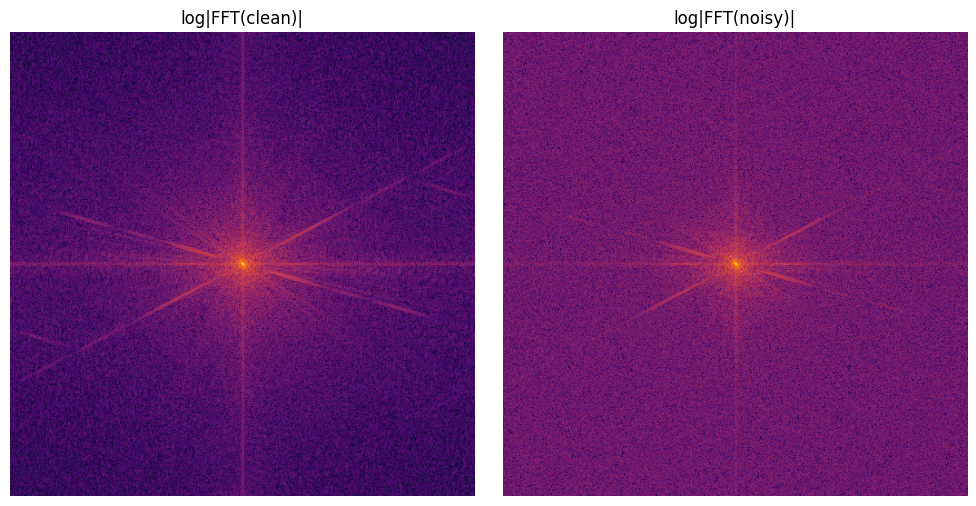

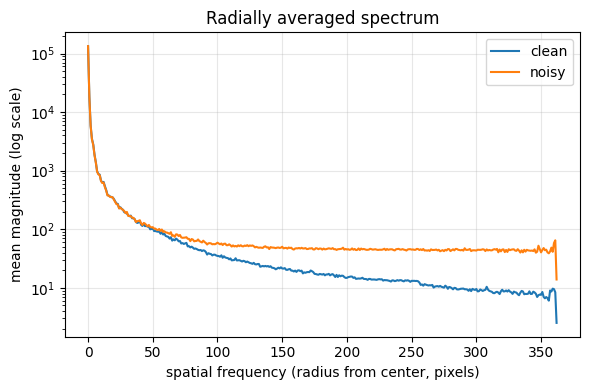

In [10]:
F_clean = np.fft.fftshift(np.fft.fft2(clean))
F_noisy = np.fft.fftshift(np.fft.fft2(noisy))

mag_clean = np.log1p(np.abs(F_clean))
mag_noisy = np.log1p(np.abs(F_noisy))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mag_clean, cmap='inferno'); axes[0].set_title('log|FFT(clean)|'); axes[0].axis('off')
axes[1].imshow(mag_noisy, cmap='inferno'); axes[1].set_title('log|FFT(noisy)|'); axes[1].axis('off')
plt.tight_layout(); plt.show()

# Radial profile: average magnitude as a function of distance from the center
def radial_profile(mag):
    cy, cx = np.array(mag.shape) // 2
    yy, xx = np.indices(mag.shape)
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2).astype(int)
    tbin = np.bincount(r.ravel(), mag.ravel())
    nr = np.bincount(r.ravel())
    return tbin / nr

rp_clean = radial_profile(np.abs(F_clean))
rp_noisy = radial_profile(np.abs(F_noisy))

plt.figure(figsize=(6, 4))
plt.plot(rp_clean, label='clean')
plt.plot(rp_noisy, label='noisy')
plt.yscale('log')
plt.xlabel('spatial frequency (radius from center, pixels)')
plt.ylabel('mean magnitude (log scale)')
plt.title('Radially averaged spectrum')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Where does the noise show up?** Gaussian (white) noise has a flat power spectrum, so it adds roughly *equal* energy at every spatial frequency, including the high frequencies (the outer regions of the shifted spectrum, far from the bright center). Natural-image energy, by contrast, is concentrated at low frequencies (the bright blob at the center) and decays quickly outward. In the log-magnitude image this appears as a noisy image whose outer regions are visibly brighter/noisier than the clean image's; in the radial-profile plot, the two curves overlap at low frequency but the noisy curve sits well above the clean curve at high frequency, forming a 'floor' set by the noise variance. This is exactly why a low-pass filter (Gaussian or box) removes noise: it attenuates those high frequencies where noise dominates, at the cost of also attenuating genuine high-frequency image detail (edges).

### Exercise 4 — Repeat the noise/denoise experiment on a brain-volume slice

We take the central axial slice (`z0`) of `volume` (real NIfTI if available, otherwise the synthetic phantom loaded in Section 3), normalize it to [0, 1], and repeat the noise-add + Gaussian-denoise + PSNR experiment from Section 4.

PSNR noisy    = 21.66 dB
PSNR denoised = 24.31 dB  (gain: +2.65 dB)


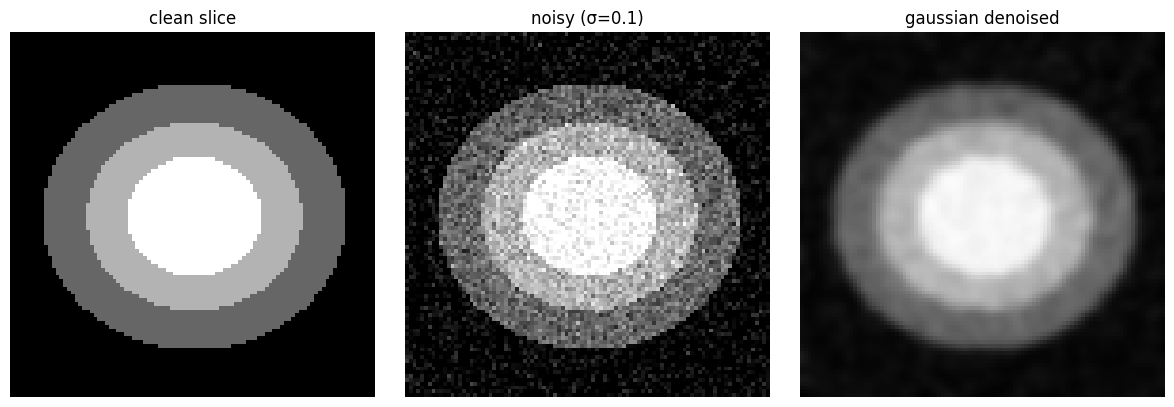

In [11]:
slice2d = volume[z0, :, :].astype(np.float32)
# normalize to [0, 1] for a fair PSNR comparison
vmin, vmax = slice2d.min(), slice2d.max()
clean_slice = (slice2d - vmin) / (vmax - vmin + 1e-8)

noisy_slice = np.clip(clean_slice + np.random.normal(0.0, 0.10, size=clean_slice.shape), 0, 1)
denoised_slice = filters.gaussian(noisy_slice, sigma=1.5)

psnr_noisy_slice    = metrics.peak_signal_noise_ratio(clean_slice, noisy_slice,    data_range=1.0)
psnr_denoised_slice = metrics.peak_signal_noise_ratio(clean_slice, denoised_slice, data_range=1.0)
print(f'PSNR noisy    = {psnr_noisy_slice:5.2f} dB')
print(f'PSNR denoised = {psnr_denoised_slice:5.2f} dB  (gain: {psnr_denoised_slice - psnr_noisy_slice:+.2f} dB)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [clean_slice, noisy_slice, denoised_slice],
                      ['clean slice', 'noisy (σ=0.1)', 'gaussian denoised']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

**Observation:** the qualitative behaviour matches the 2D `camera` case — Gaussian filtering recovers several dB of PSNR. On the synthetic phantom the gain is often *larger* than on `camera`, because the phantom is piecewise-constant (large flat regions with only a few sharp boundaries), so there's very little genuine high-frequency detail for the low-pass filter to destroy. On a real brain MRI/CT slice, expect a smaller gain than the phantom but a similar trend, since real anatomy has more fine structure (sulci, vessels, lesion boundaries) that a Gaussian filter will also blur.